# Steam Games Data Analysis & Recommendation System 

Introduction: The purpose of this project is to build a recommendation system for PC games using Steam data. We also visualize this data and answer several buisness questions such as:

    1. Which genres generate the most revenue?

    2. Games of which genres are played the most (by number of hours)?

    3. How well do positive ratings by users coorelate with the revenue generated by a game?

    4. How popular are games for which discounts are offerent as opposed to those for which none are offered?

# I. Data: Cleaning, Preprocessing & Visualizing

The data we'll use is taken from Kaggle: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

This dataset is fairly large: 122,6211 rows (games/rows) and 39 features (columns). We choose to work with the csv file instead of json since the data is mostly tabular. There are several problems with the data and we will spend a fair bit of time making the data usable. In particular:

    1. We'll drop certain features that don't give us useful information: like URLs. There are some games with zero users! We'll drop these.

    2. A few features have no values for most rows: we'll have to drop these as well.

    3. Several column names don't correspond with the values in the rows. i.e., there is a mismatch of column name and what values they contain.

    4. There might be duplicate games (this is likely because some game publishers release different versions of a game in different countries.)

Let's begin by loading the data and exploring what it looks like.

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import re
import random
import streamlit as st

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', None) # Display any number of columns.

In [354]:
df = pd.read_csv('data/games.csv')

In [355]:
df.info()

<class 'pandas.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  str    
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  str    
 9   Supported languages         122611 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     12070 non-null   str    
 12  Header image                122530 non-null  str    
 13  Website                

In [356]:
df.sample(5)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2417570,SoulForge Arena Closed Playtest,"May 26, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
555050,Racket Fury: Table Tennis VR,"Nov 9, 2017",0 - 20000,0,0,29.99,0,0,After an all-out war that took almost 2 millen...,"['English', 'Traditional Chinese', 'Simplified...",[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://PixelEdgeGames.com/,http://PixelEdgeGames.com,sboczek@PixelEdgeGames.com,True,False,False,0,NaN,0,239,51,NaN,12,265,NaN,143,0,143,0,Pixel Edge Games,Pixel Edge Games,"Single-player,Multi-player,PvP,Online PvP,Trac...","Casual,Indie,Simulation,Sports","Casual,Sports,Indie,Simulation,Tennis,VR,Fast-...",https://shared.akamai.steamstatic.com/store_it...,NaN
1759840,Crazy Fatties,"Oct 18, 2021",0 - 20000,0,0,1.99,0,0,Crazy Fatties is a casual level-breaking game....,['Simplified Chinese'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,http://xhx-underline.com/Admin/Index/login.html,whxhx2014@foxmail.com,True,False,False,0,NaN,0,4,0,NaN,17,0,NaN,0,0,0,0,武汉下划线数码科技有限公司,武汉下划线数码科技有限公司,"Single-player,Family Sharing",Casual,"3D Platformer,Casual,Sports,Action RPG,Charact...",https://shared.akamai.steamstatic.com/store_it...,NaN
1978650,Blickel,"Jan 13, 2023",0 - 20000,0,0,4.99,0,0,Blickel is a new 8-bit retro 2D platformer bas...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.vintrostudios.com/blickel,https://www.vintrostudios.com/contact,ggeffros@vintrostudios.com,True,False,False,0,NaN,0,1,0,NaN,0,0,NaN,0,0,0,0,Vintro Studios,Vintro Studios,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Indie","Precision Platformer,Side Scroller,2D Platform...",https://shared.akamai.steamstatic.com/store_it...,NaN
2804440,草地清理工,"Jul 18, 2025",0 - 0,0,0,0.00,0,0,You need to manipulate the hero's movements to...,"['Simplified Chinese', 'English']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://space.bilibili.com/304571773?spm_id_fr...,120239786@qq.com,True,False,False,0,NaN,0,0,0,NaN,0,0,This game involves adult content with certain ...,0,0,0,0,ZhiZhi,ZhiZhi,"Single-player,Full controller support","Action,Adventure,Casual,Indie,RPG,Free To Play...",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


We observe that there are several issues with this dataset. For now we focus on the features.

1. The names of the first nine features (columns) are incorrectly aligned. In particular, the feature "DiscountDLC count" should be two separate features. 
2. While the feature AppID can serve as a unique datapoint (row) identifier, we will reindex the rows using positive integers.
3. We drop features don't contain useful data or sometimes, any data (NaN) at all. In particular, several features contain only URL that are of no use. 
4. We will repurpose some features and engineer new ones from old features.
5. Features like "Categories" and "Tags" are of utmost important for our recommender system and we will need to preprocess these features, among others.
6. Etcetra... 

We will address games (rows) at a later time.

Let's rename the columns so the first nine features actually match the data they're supposed to represent. 

In [357]:
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

Let's add an index to the dataset and rename the first feature as "AppID", which is what the original index of the dataset is supposed to be. The App ID of a game is a unique number that identifies that game. We will use it below to create a new feature: the URL to the game's Steam webpage. 

In [358]:
df = df.reset_index(drop = False) # Add a column that indexes the rows using positive integers.
df.index = df.index + 1

df = df.rename(columns={'index': 'AppID'}) # Rename the original index as "AppID".

In [359]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
1,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
3,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
4,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## Feature Engineering



**Feature Selection**: We begin by dropping features that will serve us no purpose. We list them below and provide brief reasoning for dropping them. 


1. **Peak CCU**: This feature is too sparse to be useful. It's meant to be a feature indicating a game's performance and engagement. We will use other features for these metrics that are more robust and reliable. 
2. **Required age**: We assume that any user of our recommender system is an adult. Moreover, this feature is highly unreliable: many game developers enter required age as "0" even though the game may contain elements that are inappropriate for younger gamers. Additionally, we don't intend to use this feature in any of our business analysis. To make up for the loss of this, we will drop games that contain undesired elements. See [Jump to Section](#Removing-games-with-undesired-elements)
3. **Discount**: This is the feature that was tangled up with its neighbor, "DLC count" and the dataset documentation on Kaggle simply does not give information on this feature. It could be interpreted in many ways: Is it the discount % of the game at the time the dataset was created, or is it the maximum discount the game has ever seen?, etc. As such, it is impossible to include this feature in any analysis and we therefore, reluctantly, drop it.
4. **Supported languages**: A list of languages whose text is supported in a given game. Indie developers often have small budgets and this is where they cut costs. As such this feature does not give us a measure of the quality or performance of a game and so we drop it. 
5. **Full audio languages**: A list of audio languages a game supports. Niche or low budget indie games often cannot support audio in foreign languages. As such this feature is not an indicator of quality of a game, only its production budget. We will however use "Supported langauges" by coverting this feature into "Language count" that will give the number of langauges a given game supports. We intend to use this feature as a tie-breaker in our recommender system. 
6. **Website**: We will delete this feature that contains a lot of NaN fields. Instead we will create a new feature with the same name that will give the Steam webpage of a game in our recommender system.
7. **Support URL, Support email**: Links for owners of a game to get service and support. These features are not useful to us.
8. **Windows, Mac, Linux**: Boolean features telling us whether a game is supported for the given operating system. We notice below that almost all games are supported on Windows and there are only 32 games for Mac that don't run on Windows. As such, since most games are supported on Windows, we will simply get rid of these features. If our recommender ends up recommending a Linux only game to a Windows user, we trust the user will check the requirements to run the game on their computer.  
9. **Metacritic score, Metacritic url**: The vast majority of the feature "Metacritic score" is 0; this is a sparse feature. This means there is no data available. We can safely drop this feature. We also have no purpose of the corresponding URL feature.
10. **User score, user rank**: Note below that there are only 40 games that have non-zero "User score"; another sparse feature. We will also drop is statistically insignificant feature. This will affect the feature "Score rank" which is supposed to be a relative ranking of games based on "User score". As we see below, 'Score rank' contains no useful data and so we drop it as well.
11. **Achievements**: Gives the number of achievements a game offers. This number is highly unreliable. Many games offer a large number of achievements to attract gamers but the game itself lacks quality. On the other hand 100 achievements in Racing might be significaly easier (or harder) than 100 achievements in Puzzle or RPG games. As such, we don't see a way to meaningfully use this feature and therefore drop it.
12. **Recommendations**: Gives the number of recommendations a game has received across Steam's community features using the outdated Steamworks API. As we see below, this feature is very rare: about 83% values are zero. We also see that for the most popular games, this feature is highly (Pearson) correlated with "Positive". Lastly, the non-zero values of this features starts off at 101, which is rather curious. As such we drop this feature in favor of the more robust "Positive" which will be used below to create the new feature "Vote percent".
13. **Average/Median playtime forever**: These features are identical as we see below. We drop Average playtime forver and keep the latter. 
14. **Average playtime two weeks, Median playtime two weeks**: These two features are less reliable than their "forever" counterparts. They measure a game's acitivity for a very short duration of time. As such, the "forever" playtime metrics are better indicators of a game's engagement and we therefore drop these inferior features.
15. **Screenshots**: A link to a game's screenshots. Not a useful feature for us.
16. **Movies**: Contains no data; all entries are NaN. 


In [360]:
# Notice that many features are strings that are URL. Most of these are not useful to us.

df.iloc[0:5, 11:16]

,Full audio languages,Reviews,Header image,Website,Support url
1,[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN
2,[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com
3,[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames
4,['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN
5,['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com


In [361]:
# Most games run on Windows while the number of games that run on Mac or Linux but not on Windows is negligible. 

no_windows = (df['Windows'] == False).sum() / len(df) * 100
print(f"The percentage of games that don't run on Windows is {no_windows:.2f}%.")

linux_no_windows = (df[(df['Linux'] == True) & (df['Windows'] == False)].shape[0]) / len(df) * 100
print(f"The percentage of games that run on Linux but not on Windows is {linux_no_windows:.2f}%.")

mac_no_windows = (df[(df['Mac'] == True) & (df['Windows'] == False)].shape[0]) / len(df) * 100 
print(f"The percentage of games that run on Mac but not on Windows is {mac_no_windows:.2f}%.")

The percentage of games that don't run on Windows is 0.04%.
The percentage of games that run on Linux but not on Windows is 0.01%.
The percentage of games that run on Mac but not on Windows is 0.03%.


In [362]:
# A function that gives the percentage of games with a value of zero (unavailable data) for a given feature. 

def percent_zero_values(data, feature):
    percentage_zero_values = ((data[feature] == 0).sum()) / len(data) * 100
    print(f"The feature {feature} has {percentage_zero_values:.2f}% data values equal to zero.")

In [363]:
percent_zero_values(df, 'Peak CCU')
percent_zero_values(df, 'Metacritic score')
percent_zero_values(df, 'User score') # As a consequence, "Score rank" is a meaningless feature. 

The feature Peak CCU has 83.95% data values equal to zero.
The feature Metacritic score has 96.53% data values equal to zero.
The feature User score has 99.97% data values equal to zero.


In [364]:
# Average and median playtime forever are identical features. 

print((df['Average playtime forever'] != 0).sum())
print((df['Median playtime forever'] != 0).sum())
print(((df['Average playtime forever'] != 0) & (df['Median playtime forever'] != 0)).sum())
print('The above three numbers are identical, i.e., these features are non-zero for the exact same subset of games.')

# Now let's check their linear correlation. It is practically 1. 

pearson_corr = (df['Average playtime forever']).corr((df['Median playtime forever']), method = 'pearson')
print(f'The Pearson correlation of these features is {pearson_corr:.5f}.')

26119
26119
26119
The above three numbers are identical, i.e., these features are non-zero for the exact same subset of games.
The Pearson correlation of these features is 0.99421.


In [365]:
# We explore Recommendations to study its feature space.

n = ((df['Recommendations'] == 0).sum() / df.shape[0]) * 100            # About 83% of "Recommendations" is 0. 
print(f"The percentage of games with zero Recommendations is {n:.2f}.")

smallest_rec_values = sorted(df['Recommendations'].astype(object).unique())[:5]     # Notice that the non-zero recommendations start at 101. 
print(f"The five smallest Recommendation values are", *smallest_rec_values, sep = " ")

# Calculate both correlation matrices

pearson_corr = df['Positive'].corr(df['Recommendations'], method='pearson')
spearman_corr = df['Positive'].corr(df['Recommendations'], method='spearman')

print(f"Pearson Correlation (Linear): {pearson_corr:.4f}") # Positive and Recommendations are highly (Pearson) correlated. 
print(f"Spearman Correlation (Rank): {spearman_corr:.4f}")

The percentage of games with zero Recommendations is 82.95.
The five smallest Recommendation values are 0 101 102 103 104
Pearson Correlation (Linear): 0.9018
Spearman Correlation (Rank): 0.5368


In [366]:
# The feature "Movies" contains no data.

df['Movies'].notnull().astype(object).sum()

0

**Dropping Features**: We now drop all columns we wish to at the same time and take a look at what our data now looks like. Note that we are not entirely done with dropping features. We will use certain features like "About the game", "Reviews" and "AppID" and then drop them once their usage is exhausted. 

In [367]:
# Function for dropping features.

def drop_columns(data, cols):
    return data.drop(columns = cols)

In [368]:
cols = ['Peak CCU', 'Required age', 'Discount', 'Supported languages', 'Full audio languages', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 
                   'User score', 'Score rank', 'Average playtime two weeks', 'Median playtime two weeks', 'Average playtime forever', 'Achievements', 'Recommendations', 'Screenshots', 'Movies']
df = drop_columns(df, cols)

In [369]:
df = df.reset_index(drop = True) 
df.index = df.index + 1

In [370]:
df.head()

,AppID,Name,Release date,Estimated owners,Price,DLC count,About the game,Reviews,Header image,Positive,Negative,Notes,Median playtime forever,Developers,Publishers,Categories,Genres,Tags
1,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0.00,0,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,5.24,0,"Springtime, April: when the cherry trees come ...",NaN,https://shared.akamai.steamstatic.com/store_it...,252,3,NaN,8,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,4.99,0,"Immerse yourself in the most beloved, mystical...",NaN,https://shared.akamai.steamstatic.com/store_it...,21,3,NaN,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
4,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,The game includes the following elements. 1. G...,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
5,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,NaN,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN


### Data Preprocessing

**Duplicate Rows**: Let's start by checking if there are duplicate rows. Duplicate rows will have identical entires for each feature. The pandas function drop_duplicates() will keep one copy while tossing out the other duplicate ones. 

In [371]:
n = df.duplicated().sum() # Number of duplicate rows.
print(f"There are {n} duplicate rows.")

df = df.drop_duplicates() # Our dataframe now contains no duplicate rows.

There are 0 duplicate rows.


We now take a look at each feature and prepare it for analysis. 

In [372]:
df['Name'].describe()

count                                            122610
unique                                           121454
top       Shadow of the Tomb Raider: Definitive Edition
freq                                                 20
Name: Name, dtype: object

**A Big Question: What do we do with games with duplicate names?**

There are games in the dataset with the exact same name. There are a few main reasons for this: 
1. The game was relased in a different region (and perhaps in a different language) of the world at a different time than its original release.
2. A slightly different version of the game was released (director's cut, extended edition, anniversary edition, remaster, etc.) but the name was the game was kept identical.
3. Several games could be named "Solitarie" but could be developed by different developers and as such, could be different games in terms of experience. 

We must decide how to handle this problem. There are two options:

    A. Keep the duplicates. The recommender will anyways be constructed to choose the best performing one, in case of a tie between two versions of a game with the same name.

    B. Keep only the best performing version: We could sort the games by metrics of performance: Peak CCU and/or Revenue (feature to be introduced below) and then we keep only the top version of the game. 

Decision: We keep the games with duplicate names. Note that these are not true duplicates: they differ in terms of other features. Moreover, all games have a unique AppID and we will use this when recommending games. It is best not to throw out data unless absolutely necessary. 

**Games with no Name**: Next, we check if there are any games with no name. As we see below, there is one, interestingly. We can use this game's AppID to visit the  [Steam webpage](https://store.steampowered.com/app/396420/_/) for this game and check that there indeed is no name for the game and the webpage is missing a lot of other information. We'll have to drop this game.  

In [373]:
df[df['Name'].isnull()]

,AppID,Name,Release date,Estimated owners,Price,DLC count,About the game,Reviews,Header image,Positive,Negative,Notes,Median playtime forever,Developers,Publishers,Categories,Genres,Tags
44433,396420,NaN,"Nov 1, 2016",0 - 0,0.0,0,Spookeningは3Dの恐怖ゲームで、あなたは毎夜に死んでゴーストとして復活します。 村...,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [374]:
df.dropna(subset=['Name'], inplace=True) # Drop the row with the null "Name".

**Release date**: We convert release date to a consistent format: YYYY-MM-DD and make sure that there are no errors, for example, 2028-20-41.  

In [375]:
converted_dates = pd.to_datetime(df['Release date'], errors = 'coerce') # Convert release date to the default pandas format: datetime64[ns] displayed as YYYY-MM-DD
bad_dates = df[converted_dates.isna()] # Check for any NaT (Not a Time) values. 
print(bad_dates['Release date'].unique())

<StringArray>
[]
Length: 0, dtype: str


In [376]:
df['Release date'] = pd.to_datetime(df['Release date']) # Convert release date to the default pandas format: datetime64[ns] displayed as YYYY-MM-DD

years = df['Release date'].dt.year.unique().tolist() # Make sure the year of release falls within in the expected range
print(f'The list of years in which a game was released is', sorted(years))

months = df['Release date'].dt.month.unique().tolist() # Make sure the month of release falls within the expected range
print(f'The list of months in which a game was released is', sorted(months))

days = df['Release date'].dt.day.unique().tolist() # Make sure the day of release falls within the expected range 
print(f'The list of days of a month on which a game was released is', sorted(days))

The list of years in which a game was released is [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
The list of months in which a game was released is [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
The list of days of a month on which a game was released is [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


"Release date" is now in a consistent format and all numbers representing a date fall within the expected range.

## **Feature Extraction** 

We now create a few new useful features using the ones we already have. Note that we aren't necessarily aiming to reduce dimensionality of your dataset just yet. 

**New Feature: Game age**: We create this new feature that will help us normalize revenue generated by a game per year later on. We require this feature to be in number of years accurate to two decimal places. Since every fourth year has 366 days, it will be slightly more appropriate to use a year as 365.25 days below. Please note that Game age is calculated with respect to the date this code was written: May 6, 2026. :)

In [377]:
from datetime import date

today = pd.Timestamp('2026-05-06')

df['Game age'] = ((today - df['Release date']) / pd.Timedelta(days = 365.25)).round(2)

Let us verify that this feature is producing the age of a game as expected. The game [Stardew Valley](https://store.steampowered.com/app/413150/Stardew_Valley/) came out in Feb, 2016, so the expected age of this game is a little more than 10 years. 

In [378]:
print(df.loc[df['Name'] == 'Stardew Valley', 'Game age']) # The output below is as expected. 

95881    10.19
Name: Game age, dtype: float64


**New Feature: Website**: It gives the URL of the Steam webpage of a game. We use the feature "AppID" to construct this feature, which contains no NaN objects, so we are ready to use it. This is the correct way to record a game's Steam URL. Steam uses a consistent URL format for all games as outlined in the code below. 

In [379]:
df['Website'] = 'https://store.steampowered.com/app/' + df['AppID'].astype(str) + '/' 

df.loc[df['Name'] == 'The Talos Principle', 'Website'] # The feature works as intended. Go ahead and check out this game by clicking the link below. It's awesome!

53776    https://store.steampowered.com/app/257510/
Name: Website, dtype: str

**Redefining Estimated owners**: This feature is a string that gives an estimated range of the number of owners of a game. We will use this range to get an estimate of the number of owners as one single number. In this case, we choose this estimate to be the mean of the range. The mean is a crude but appropriate measure of central tendency in this scenario. The main purpose of this feature is to help estimate yearly revenue generated by a game. 

In [380]:
# Split the 'Estimated owners' column into two temporary columns
owners_split = df['Estimated owners'].str.split('-', expand=True).astype(float)

# Calculate the average of the range owners_split[0] is the low end, owners_split[1] is the high end
df['Estimated owners'] = (owners_split[0] + owners_split[1]) / 2

**New Feature: Estimated yearly revenue**: We would like to get an estimate of the revenue generated per year by each game. To do this, we define Estimated revenue = (Average owners X Price) / Game age. We keep in mind the following facts about game pricing in mind:

1. Since "Price" is in USD, we are ignoring the fact that games are also bought by people outside the US using currencies different from the USD.
2. Many games go on discount a few times a year so the actual revenue generated is typically lower.
3. Steam takes a cut from the price a buyer pays for a game so the actual revenue a game developer generates is smaller. Similarly, several other "middle men" take their cut, for example, the game publisher, game promoters, etc.
4. There are "fremium" games. These games are free to download and play but may inlude paid additional content.
5. Many modern games have DLCs, i.e., domnloadble content which is typically paid and may generate revenue beyond the original purchase of the game. 
6. Lastly, the entries in the feature "Price" are proabably recorded at the time this dataset was created and the typical price of a game may fluctuate over time.
   
Of course, this is far from an ideal estimate, but nonetheless, "Estimated revenue" will give us an indication of how a paid game has performed financially. We keep in mind that "Estimated revenue" will typically be a gross upper bound of the actual revenue generated by the game. 

In [381]:
df['Estimated yearly revenue'] = (df['Estimated owners'] * df['Price']) / df['Game age']

In [382]:
df['Estimated yearly revenue'].describe()

count    1.226100e+05
mean     1.977647e+05
std      9.827208e+06
min      0.000000e+00
25%      0.000000e+00
50%      6.939724e+03
75%      2.806465e+04
max      2.631140e+09
Name: Estimated yearly revenue, dtype: float64

Now observe that "Estimated yearly revenue" has a large range. We will therefore use a logrithm tranform to better represent revenue. Next, we need all our values between 0 and 1 so we use the MinMaxScaler to achieve this. It is obvious why one shouldn't directly apply MinMaxScaler without the log transform. For convenience sake, we preserve the name of this feature, even though we are transforming it. 

In [383]:
df['Estimated yearly revenue'] = np.log10(df['Estimated yearly revenue'] + 1) # We add 1 since log 0 is undefined. This gives a nice consistent scale from 0 to around 9.

df['Estimated yearly revenue'] = MinMaxScaler().fit_transform(df[['Estimated yearly revenue']]) # Apply the MinMaxScaler

df['Estimated yearly revenue'].describe()

count    122610.000000
mean          0.331745
std           0.206498
min           0.000000
25%           0.000000
50%           0.407786
75%           0.472198
max           1.000000
Name: Estimated yearly revenue, dtype: float64

Let's reorder the games by "Estimated yearly revenue" in descending to see if we recognize some of the games and list out the top 20 games by yearly revenue. This seems like a more appropriate head for this dataset!

In [384]:
df = df.sort_values(by = 'Estimated yearly revenue', ascending = False); # Sort the games by yearly revenue.

df = df.reset_index(drop = True) # Reset index 
df.index = df.index + 1

Let's see the top twenty games by Estimated yearly revenue. 

In [385]:
df.iloc[0:20, 1] 

1              Black Myth: Wukong
2            Monster Hunter Wilds
3             New World: Aeternum
4                 Path of Exile 2
5                        Palworld
6                 Baldur's Gate 3
7                   HELLDIVERS™ 2
8                      Last Epoch
9                EA SPORTS FC™ 25
10                     ELDEN RING
11                   Satisfactory
12                  7 Days to Die
13              Battlefield™ 2042
14                     Schedule I
15                           SCUM
16                      CyberCorp
17                 Cyberpunk 2077
18    Clair Obscur: Expedition 33
19                 Battlefield™ V
20                       Hades II
Name: Name, dtype: str

In [386]:
# A function to plot the distribution of a continuous feature as histogram. 

def plot_feature(dataframe, feature, title, xlabel, ylabel):
    sns.set_theme(style = 'whitegrid')
    plt.figure(figsize = (16,6))
    sns.histplot(data = dataframe, x = feature, bins = 50, kde = False) # 50 bins works fairly well for datasets of this size. When using much larger or smaller datasets, this will need adjusting.
    plt.title(title, fontsize = 14)
    plt.xlabel(xlabel, fontsize = 12)
    plt.ylabel(ylabel, fontsize = 12)
    plt.show()

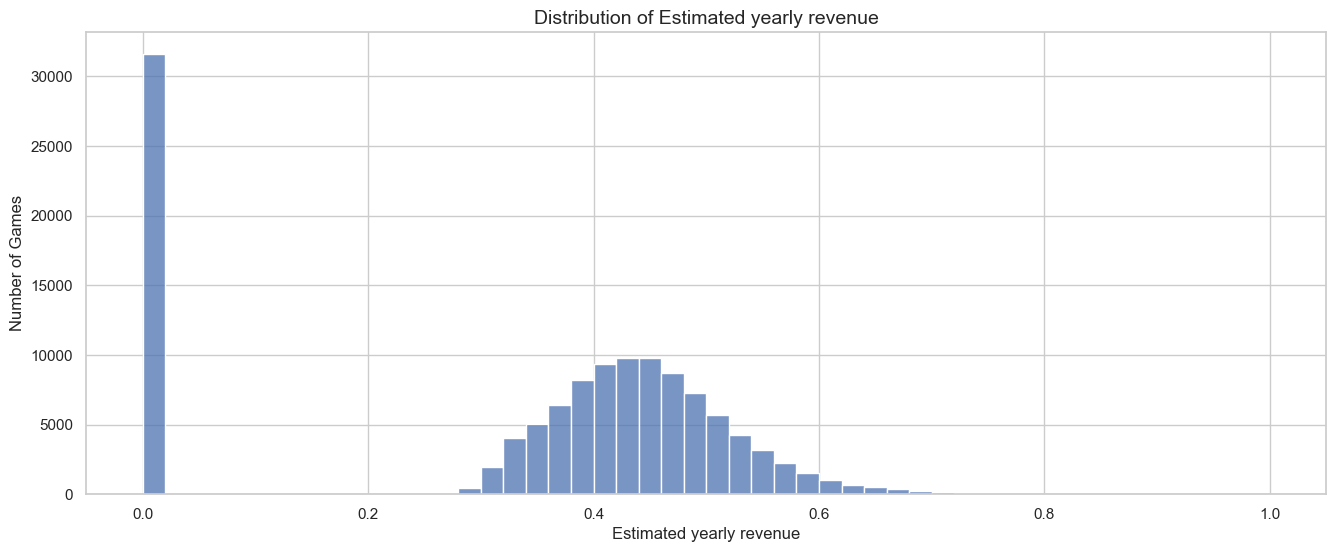

In [387]:
plot_feature(df, 'Estimated yearly revenue', 'Distribution of Estimated yearly revenue', 'Estimated yearly revenue', 'Number of Games')

As expected, ignoring the free to play games, the rest of the data follows a normal distribution. 

Now we also scale the feature Estimated owners. Like before, we'll first apply a log-transform and then the MinMaxScaler. The reason is that without the log-transform, MinMaxScaler will squash the majority of the games with fewer owners close to zero. 

In [388]:
df['Estimated owners'] = np.log10(df['Estimated owners'] + 1) # We add 1 since log 0 is undefined. This gives a nice consistent scale from 0 to around 9.

df['Estimated owners'] = MinMaxScaler().fit_transform(df[['Estimated owners']]) # Apply the MinMaxScaler

In [389]:
df['Estimated owners'].describe()

count    122610.000000
mean          0.427644
std           0.205604
min           0.000000
25%           0.489237
50%           0.489237
75%           0.489237
max           1.000000
Name: Estimated owners, dtype: float64

**New Feature: Vote Percent**: This feature gives the percentage of positive votes. We use the features "Positive" and "Negative" to do this. This operation will return NaN precisely when there are no positive or negative votes. In this case, we will set the vote percent of such a game to 0.  

In [390]:
df['Vote percent'] = df['Positive'] / (df['Positive'] + df['Negative']) * 100 

In [391]:
df['Vote percent'].isnull().sum() 

np.int64(39661)

In [392]:
df['Vote percent'] = df['Vote percent'].fillna(0) # Let's set NaN values to 0. We'll use Bayesian statsitics to rigorously address this later. 

As an example, let's check the Vote percent of the game [Stardew Valley](https://store.steampowered.com/app/413150/Stardew_Valley/). It's identical (rounded to the closest integer) to what you'll see on the Steam webpage for the game.

In [393]:
df.loc[df['Name'] == 'Stardew Valley', 'Vote percent']

78    98.441539
Name: Vote percent, dtype: float64

## A Bayesian Approach

Suppose Game A has 3 positive votes and 0 negative votes. Its Vote percent is 100%. Suppose Game B has 10,000 positive votes and 720 negative votes. It's Vote percent is 93%. But raw ranking of games based on Vote percent will favor Game A over Game B. This is a huge problem since Game A lacks voting data. To rectify this, we employ a Bayesian approach to scale this feature so that in the above scenario, Game B is favored far heavier over Game A. 

Overview of the logic: 

1. Likelihood: The features Positive and Negative give us our Bayesian likelihood. Since a vote can be either positive or negative, we model votes using the binomial distribution.
2. Prior: This is what we believe the votes in our dataset behaves like on average. We want the values of scaled Vote percent to fall between 0 and 1. This scale is continuous. The Beta distribution is desgined precisely for such a scenario.

Objective: Given the Prior, we seek to obtain an updated probability (Posterior) based on available voting data (Likelihood). 




In [394]:
# Convert Vote percent to numbers between 0 and 1.

C = (df['Vote percent'] / 100).mean()

# We choose the median number of total votes as our volume threshold, i.e., the number of "ghost votes" we wish to weigh against games with a low volume of votes. 

m = (df['Positive'] + df['Negative']).median()

# Introduce Bayesian parameters.

a_global = m * C

b_global = m * (1 - C)

# Define the posterior. 

df['Bayesian votes'] = (df['Positive'] + a_global) / ((df['Positive'] + df['Negative']) + (b_global + a_global))

In [395]:
df['Bayesian votes'].describe() # A quick check to see the range is [0,1].

count    122610.000000
mean          0.632801
std           0.153857
min           0.105009
25%           0.512994
50%           0.575389
75%           0.756497
max           0.995773
Name: Bayesian votes, dtype: float64

In [396]:
df = df.sort_values(by = 'Bayesian votes', ascending = False) # Let's reorder the dataset by Bayesian votes. 

Here are the top 10 games by bayesian votes. Heading over to the Steam webpage for any of these games shows that it has overwhelmingly positive votes. 

In [397]:
df.iloc[0:10, 1]

8653                                         Kabuto Park
7301      Aokana - Four Rhythms Across the Blue - EXTRA2
114289                                   The WereCleaner
11811                              A Castle Full of Cats
15060                               A Tower Full of Cats
3028                                         Beastieball
2872                             Papa's Freezeria Deluxe
18137                                         Seal World
4722                             TOEM: A Photo Adventure
6002                                        A Short Hike
Name: Name, dtype: str

Here are the bottom 10 games by bayesian votes. Some of these games have no votes at al or have overwhelmingly negative votes.  

In [398]:
df.iloc[-10:, 1]

30020                         Chess
8925                Age of Survival
66946                10 Years After
38555                      Only Up!
53979                     CornField
71939      Heroes in the Sky-Origin
21649            PawnShop Simulator
37479    Construction Machines 2014
58121                 Drunk Wizards
8231                   SuperPower 3
Name: Name, dtype: str

**Case Study**: Let's find two games with similar Votes percent but one having significantly more total votes than the other. The Bayesian votes score for these should be drastically different. 

In [399]:
df.loc[((df['Positive'] == 3) & (df['Negative'] == 0)), 'Name'][:3]

45077              Time Avarice
80385    Attack of the Gooobers
11931                 Alien Age
Name: Name, dtype: str

In [400]:
df.loc[((df['Positive'] == 96) & (df['Negative'] == 3)), 'Name'][:3]

28900    The Mystery of Caketropolis
78862                   Recollection
Name: Name, dtype: str

In [401]:
# Let's choose the games Alien Age and Recollection. Find their Vote percent

print(df.loc[df['Name'] == 'Alien Age', 'Vote percent'])
print(df.loc[df['Name'] == 'Recollection', 'Vote percent'])

11931    100.0
Name: Vote percent, dtype: float64
78862    96.969697
Name: Vote percent, dtype: float64


In [402]:
# Find their Bayesian votes now.

print(df.loc[df['Name'] == 'Alien Age', 'Bayesian votes'])
print(df.loc[df['Name'] == 'Recollection', 'Bayesian votes'])

11931    0.659096
Name: Bayesian votes, dtype: float64
78862    0.939537
Name: Bayesian votes, dtype: float64


**Conclusion**: Note that even though the game Alien Age has only 3 total votes, it has a 100% Vote percent whereas it's Bayesian votes score is ~0.66, which is close to the mean of the Bayesian votes feature. On the other hand, the game Recollection has a lower Votes percent but a significantly higher Bayesian votes score since it has a larger number of total votes, which makes its positive votes all the more precious. The feature Bayesian votes is working as expected. 

## Categorical Featues 

Data Dictionary: Label: Genres, Categories, Tags, Publishers and Developers are categorical features that contains lists of strings as objects. Each string in such a list will be termed a 'label'. 

### Genres, Categories & Tags

These are the most important categorical features in our project and they will strongly influence our recommender system. We start by cleaning and preprocessing them first.  

The function we define below gives a wondeful way to look at the feature space of a categorical variable holding lists of comma separated strings. 

In [403]:
# A function that prints out all the unique labels of a categorical feature that holds a list of strings. 

def unique_labels(data, feature):
    
    all_labels = []

    for entry in data[feature].dropna():
        labels = [g.strip().lower() for g in entry.split(",")]
        all_labels.extend(labels)

    unique_labels = sorted(set(all_labels))

    return unique_labels

We now take a look at "Genres", "Categories" and "Tags". These features are very important for constructing our recommender system. We see with a quick glance below that "Genres" looks fine but "Categories" and "Tags" deserves a closer look considering the large number of unique values it admits. 

In [404]:
print(unique_labels(df, 'Genres'))

['360 video', 'accounting', 'action', 'adventure', 'animation & modeling', 'audio production', 'casual', 'design & illustration', 'documentary', 'early access', 'education', 'episodic', 'free to play', 'game development', 'gore', 'indie', 'massively multiplayer', 'movie', 'nudity', 'photo editing', 'racing', 'rpg', 'sexual content', 'short', 'simulation', 'software training', 'sports', 'strategy', 'tutorial', 'utilities', 'video production', 'violent', 'web publishing']


In [405]:
print(unique_labels(df, 'Categories'))

['adjustable difficulty', 'adjustable text size', 'camera comfort', 'captions available', 'chat speech-to-text', 'chat text-to-speech', 'co-op', 'color alternatives', 'commentary available', 'cross-platform multiplayer', 'custom volume controls', 'family sharing', 'full controller support', 'hdr available', 'in-app purchases', 'includes level editor', 'includes source sdk', 'keyboard only option', 'lan co-op', 'lan pvp', 'mmo', 'mods', 'mods (require hl2)', 'mouse only option', 'multi-player', 'narrated game menus', 'online co-op', 'online pvp', 'partial controller support', 'playable without timed input', 'pvp', 'remote play on phone', 'remote play on tablet', 'remote play on tv', 'remote play together', 'save anytime', 'shared/split screen', 'shared/split screen co-op', 'shared/split screen pvp', 'single-player', 'stats', 'steam achievements', 'steam cloud', 'steam leaderboards', 'steam timeline', 'steam trading cards', 'steam turn notifications', 'steam workshop', 'steamvr collectib

Glancing over "Categories", we notice that most of it is fine except there are two entries "VR Supoort" and "VR Supported" that should be unfied to one: "VR Supported".

In [406]:
sorted(df.loc[df['Name'] == 'The Talos Principle', 'Tags'])

['Puzzle,Philosophical,First-Person,Sci-fi,Atmospheric,Story Rich,Singleplayer,Great Soundtrack,Robots,Exploration,Adventure,Indie,Multiple Endings,Difficult,Mystery,Post-apocalyptic,Action,Simulation,Science,Artificial Intelligence']

In [407]:
df["Categories"] = df['Categories'].str.replace(r'\bVR Support\b', 'VR Supported', regex = True)

Let's check that "VR Support" and "VR Supported" have been merged into "VR Supported". 

In [408]:
print(unique_labels(df, 'Categories'))

['adjustable difficulty', 'adjustable text size', 'camera comfort', 'captions available', 'chat speech-to-text', 'chat text-to-speech', 'co-op', 'color alternatives', 'commentary available', 'cross-platform multiplayer', 'custom volume controls', 'family sharing', 'full controller support', 'hdr available', 'in-app purchases', 'includes level editor', 'includes source sdk', 'keyboard only option', 'lan co-op', 'lan pvp', 'mmo', 'mods', 'mods (require hl2)', 'mouse only option', 'multi-player', 'narrated game menus', 'online co-op', 'online pvp', 'partial controller support', 'playable without timed input', 'pvp', 'remote play on phone', 'remote play on tablet', 'remote play on tv', 'remote play together', 'save anytime', 'shared/split screen', 'shared/split screen co-op', 'shared/split screen pvp', 'single-player', 'stats', 'steam achievements', 'steam cloud', 'steam leaderboards', 'steam timeline', 'steam trading cards', 'steam turn notifications', 'steam workshop', 'steamvr collectib

### Cleaning up Tags

In [409]:
print(unique_labels(df,'Tags'))

['1980s', "1990's", '2.5d', '2d', '2d fighter', '2d platformer', '360 video', '3d', '3d fighter', '3d platformer', '3d vision', '4 player local', '4x', '6dof', '8-bit music', 'abstract', 'action', 'action roguelike', 'action rpg', 'action rts', 'action-adventure', 'addictive', 'adventure', 'agriculture', 'aliens', 'alternate history', 'ambient', 'america', 'animation & modeling', 'anime', 'arcade', 'archery', 'arena shooter', 'artificial intelligence', 'assassin', 'asymmetric vr', 'asynchronous multiplayer', 'atmospheric', 'atv', 'audio production', 'auto battler', 'automation', 'automobile sim', 'base-building', 'baseball', 'based on a novel', 'basketball', 'batman', 'battle royale', "beat 'em up", 'beautiful', 'benchmark', 'bikes', 'birds', 'blood', 'bmx', 'board game', 'boomer shooter', 'boss rush', 'bowling', 'boxing', 'building', 'bullet hell', 'bullet time', 'capitalism', 'card battler', 'card game', 'cartoon', 'cartoony', 'casual', 'cats', 'character action game', 'character cus

Visually inspecting the feature space of "Tags" gives us an idea that the feature is *mostly* clean. Tags is a very important feature for Steam as a company, so it is not surprising that it is incredibly clean. Nonetheless, we do our due diligence to find any typos or redundant tags. This can be achieved by surfacing up the least used tags, since this is where typos usually live. 

In [410]:
# Clean the brackets/quotes and split the tags by commas into a Python list
clean_tags = df['Tags'].str.replace(r"[\[\]']", "", regex=True).str.split(",")

# Explode the lists so every tag gets its own row, strip whitespace, and count them
tag_counts = clean_tags.explode().str.strip().value_counts()

# Find the threshold value for the bottom 10% of unique tags
bottom_10_threshold = tag_counts.quantile(0.10)

# Filter out the tags that fall below or equal to this threshold
noise_tags = tag_counts[tag_counts <= bottom_10_threshold]

print(f'The bottom 10% threshold is: {bottom_10_threshold} occurrences.')
print(f'Number of unique tags classified as noise: {len(noise_tags)}')
print('\nThe 10%  of least used Tags are:')
print(noise_tags.tail(len(noise_tags)))

The bottom 10% threshold is: 80.4 occurrences.
Number of unique tags classified as noise: 46

The 10%  of least used Tags are:
Tags
Boss Rush             80
Instrumental Music    80
Skateboarding         79
Motocross             79
Mod                   78
Lemmings              76
Hockey                75
Based On A Novel      74
Skating               72
Bowling               64
Warhammer 40K         55
Well-Written          54
BMX                   53
Skiing                52
8-bit Music           52
Shop Keeper           46
Rock Music            46
Snowboarding          44
Electronic            43
Voice Control         42
Dice                  40
ATV                   39
Extraction Shooter    38
Birds                 36
Musou                 36
TrackIR               35
Coding                33
Documentary           32
Fox                   30
Cricket               29
Masterpiece           28
Benchmark             27
Hardware              24
Volleyball            22
Rugby             

Verdict: We don't find any typos. More importantly, there aren't any tags that are meaningless or redundant and so we don't drop any tags. 

We now check whether there are any labels shared by Genres, Categories and Tags. This is easily achieved by recasting unique labels as a Python set. 

In [411]:
# Lets find the number of unique labels for these features. 

print('The number of unique Genres is', len(unique_labels(df, 'Genres')))
print('The number of unique Categories is', len(unique_labels(df, 'Categories')))
print('The number of unique Tags is', len(unique_labels(df, 'Tags')))   

The number of unique Genres is 33
The number of unique Categories is 57
The number of unique Tags is 452


In [412]:
set_genres = set(unique_labels(df, 'Genres')) 
set_categories = set(unique_labels(df, 'Categories'))
set_tags = set(unique_labels(df, 'Tags'))

In [413]:
genres_intersect_categories = set_genres & set_categories
print('The labels common to both Genres and Categories are', genres_intersect_categories) # set() is an empty set. 

The labels common to both Genres and Categories are set()


In [414]:
categories_intersect_tags = set_categories & set_tags
print('The labels common to both Categories and Tags are', categories_intersect_tags)

The labels common to both Categories and Tags are {'vr only', 'pvp', 'co-op', 'online co-op'}


In [415]:
genres_intersect_tags = set_genres & set_tags
print('The labels common to both Genres and Tags are', sorted(genres_intersect_tags))

The labels common to both Genres and Tags are ['360 video', 'action', 'adventure', 'animation & modeling', 'audio production', 'casual', 'design & illustration', 'documentary', 'early access', 'education', 'episodic', 'free to play', 'game development', 'gore', 'indie', 'massively multiplayer', 'movie', 'nudity', 'photo editing', 'racing', 'rpg', 'sexual content', 'short', 'simulation', 'software training', 'sports', 'strategy', 'tutorial', 'utilities', 'video production', 'violent', 'web publishing']


We have discovered that these features are not disjoint, they share certain labels. This is highly problematic if left untreated since one hot encoding will gives multiple features with the same name. This will artifically boost games in the recommender if a label appears in for example, both Genres and Tags.

**Unify Genres, Categories & Tags**: To address the above issue, we will create one master feature called "Characteristics" which will be a concatenation of Genres, Categories and Tags. We will then cast this feature as a set to eliminate duplicates and then recast it into a format that the CountVectorizer (our one hot encoder) accepts. 

In [416]:
# Function that merges categorical features: Processes a single row of data, extracts elements from specified columns, deduplicates them using a set, and returns a string.

def unify_categorical_features(row, features):
    
    master_feature = []

    for feature in features:
        # Check if the cell has data (isn't NaN or empty)
        if pd.notna(row[feature]) and str(row[feature]).strip() != "":
            # Split the comma-separated string into discrete labels
            labels = [label.strip().replace(' ', '').lower() for label in str(row[feature]).split(',')]
            
            # Extend our master list with these labels
            master_feature.extend(labels)

    # Convert to a set to remove repetitions, then join into a space-separated string
    return ' '.join(set(master_feature))


In [417]:
target_features = ['Genres', 'Categories', 'Tags']

df['Characteristics'] = df.apply(unify_categorical_features, axis = 1, features = target_features)

Now lets investigate if Characteristics is welld defined by checking if it has any NaN values. 

In [418]:
df['Characteristics'].isnull().sum()

np.int64(0)

It seems Characteristics has no missing data but this should match with how we've defined the feature. There should be no games that miss Genres, Categories and Tags data simultaneously. We see below that this is not the case and we must address this discrepancy. 

In [419]:
missing_count = ((df['Genres'].isnull()) & (df['Categories'].isnull()) & (df['Tags'].isnull())).sum()
print('The number of games missing Genres, Categories and Tags data is', missing_count)

The number of games missing Genres, Categories and Tags data is 7983


In [420]:
# Let's find the list of games that's missing all three features (Genres, Categories and Tags) simultaneously. 

mask = df['Genres'].isnull() & df['Categories'].isnull() & df['Tags'].isnull()

# 2. Filter the DataFrame
missing_all_three = df.loc[mask]
print(missing_all_three['Name'])

108775        SteamVR Driver for FOVE
121222      Hollow Survivors Playtest
121220               Shattle Playtest
121214    Fi da Puti Samurai Playtest
121212      The Unfound Soul Playtest
                     ...             
109867                  SVSV Playtest
109866            Roger that Playtest
109864        The Black Swan Playtest
109862      The Glitch Fairy Playtest
122592            CyberVault Playtest
Name: Name, Length: 7983, dtype: str


**Removing Playtests**: We discover that there are a bunch of "Playtest games". These are beta trials of games that developers test on the Steam platform and as such are not real games. That is why they are lacking the metadata features Genres, Categories and Tags. We should absolutely drop them since they aren't real games, just noise in the dataset. 

In [421]:
df = df[~df['Name'].str.contains('playtest', case=False, na=False)]
print('We\'ve removed playtest builds. Number of games in dataset', len(df))

We've removed playtest builds. Number of games in dataset 114481


In [422]:
missing_count = ((df['Genres'].isnull()) & (df['Categories'].isnull()) & (df['Tags'].isnull())).sum()
print('The number of games missing Genres, Categories and Tags data is', missing_count)

The number of games missing Genres, Categories and Tags data is 128


In [423]:
# 1. Create the mask and filter
mask = df['Genres'].isnull() & df['Categories'].isnull() & df['Tags'].isnull()
missing_all_three = df.loc[mask]

# 2. Print the entire list of names without truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_all_three['Name'])

108775                              SteamVR Driver for FOVE
121156                              OutcastKidsAndCity DEMO
120733                                  The King Of Truancy
120626                                     IRON EVIL - Beta
120457                              Nightmare Invasion Beta
120427                    Warlords Battleground: Extraction
120396                                     Eruption DevTest
119895                                No Time To Die - Test
119617                       One Military Camp Private Beta
119209                      Millennium Strategy (Beta Test)
119189                                              Boo Men
118573                                 ODDCORE: First Shift
118356                                        Nefarium Beta
118344                              Polygon of Reality Beta
117868                                    KILLER INN - BETA
117841                                       Ipseity: Arena
117742                         Tavern Ke

In [424]:
df.loc[df['Name'] == 'Beauty VS Zombie', 'Tags']

108273    NaN
Name: Tags, dtype: str

In [425]:
df.loc[df['Name'] == 'Beauty VS Zombie', 'Characteristics']

108273    
Name: Characteristics, dtype: str

In [426]:
# This regex pattern matches empty strings, pure spaces, or any combination of commas and spaces and sets them to NaN.
df['Characteristics'] = df['Characteristics'].replace(r'^[,\s]*$', np.nan, regex=True)

# Check the missing count again to verify it worked!
new_missing_count = df['Characteristics'].isnull().sum()
print(f"Now, 'Characteristics' shows {new_missing_count} missing values.")

Now, 'Characteristics' shows 128 missing values.


The number of games missing Genres, Categories and Tags data simultaneously is 128, whereas now, Characteristics shows 192 missing values. This is still a discrepancy, but way smaller than the previous one.

We note that there are a small number (~100) of "games" containing the words "beta", "test", "demo". A lot of these are not real games but rather non-playable versions of games that developers test on Steam. We don't clean these up: the reason is that this noise is insignificant for our RS as these will not surface up as highly recommendable games anyway. Moreoever, there are actualk games contains these words (perhaps as subwords) that risk deletion if we decide to clean up this noise. 

In [427]:
# 1. Get the unique words array
unique_words = df['Characteristics'].str.split().explode().unique()

# 2. List comprehension to drop anything that isn't a string (removes float nans)
clean_unique_words = [word for word in unique_words if isinstance(word, str)]

# 3. This will now sort perfectly with zero errors!
print(f"Total unique words: {len(clean_unique_words)}")
print(sorted(clean_unique_words))

Total unique words: 506
['1980s', "1990's", '2.5d', '2d', '2dfighter', '2dplatformer', '360video', '3d', '3dfighter', '3dplatformer', '3dvision', '4playerlocal', '4x', '6dof', '8-bitmusic', 'abstract', 'accounting', 'action', 'action-adventure', 'actionroguelike', 'actionrpg', 'actionrts', 'addictive', 'adjustabledifficulty', 'adjustabletextsize', 'adventure', 'agriculture', 'aliens', 'alternatehistory', 'ambient', 'america', 'animation&modeling', 'anime', 'arcade', 'archery', 'arenashooter', 'artificialintelligence', 'assassin', 'asymmetricvr', 'asynchronousmultiplayer', 'atmospheric', 'atv', 'audioproduction', 'autobattler', 'automation', 'automobilesim', 'base-building', 'baseball', 'basedonanovel', 'basketball', 'batman', 'battleroyale', "beat'emup", 'beautiful', 'benchmark', 'bikes', 'birds', 'blood', 'bmx', 'boardgame', 'boomershooter', 'bossrush', 'bowling', 'boxing', 'building', 'bullethell', 'bullettime', 'cameracomfort', 'capitalism', 'captionsavailable', 'cardbattler', 'card

### Cleaning Up Characteristics

Now that we have one feature that characterizes a game, we can proceed with cleaning it. We use our gaming domain knowledge to go through the feature space of characteristics to identify labels we can drop and others that we can merge and standardize. 

1. We remove labels that don't describe a game and rather describe nice-to-have Steam infrastructure.
2. We strip labels of any spaces and standardize punctuation within labels.
3. We use regex to merge several labels that imply other labels. (for example, VR_only implies VR_available, etc.)

In [428]:
# Function to clean up a feature that contains long strings separated by spaces. 

def feature_cleaner(label):
    
    # 0. Convert to lowercase and strip whitespace.
    
    l = label.lower().strip()
    
    # 1. Drop labels that decribe characteristics of the gaming platform and not the game itself.
    
    infrastructure_blacklist = {
        'steamachievements', 'steamcloud', 'steamleaderboards', 'steammachine', 
        'steamtimeline', 'steamtradingcards', 'steamturnnotifications', 'steamvrcollectibles', 
        'steamworkshop', 'valveanti-cheatenabled', 'familysharing', 'captionsavailable',
        'hdravailable', 'benchmark', 'cameracomfort', 'photoediting', 
        'videoproduction', 'webpublishing', 'subtitleoptions',
        'chatspeech-to-text', 'chattext-to-speech', 'narratedgamemenus', 'adjustabledifficulty',
        'adjustabletextsize'
    }
    if l in infrastructure_blacklist:
        return None
        
    # 2. Standardize hyphens, slashes, ampersands, and apostrophes.
    
    l = l.replace('-', '').replace('/', '').replace("'", "").replace('’', '')
    l = l.replace('&', 'and')
    
    # 3. Structural regex collapses
    
    l = re.sub(r'^(online|local|lan|4player)?coop(campaign)?$', 'coop', l)
    l = re.sub(r'^(multiplayer|multi-player)$', 'multiplayer', l)
    l = re.sub(r'^(singleplayer|single-player)$', 'singleplayer', l)
    l = re.sub(r'^vr(only|supported)?$', 'vr', l)
    l = re.sub(r'^(full|partial|tracked)?controllersupport$', 'controller', l)
    l = re.sub(r'^mouseonly(option)?$', 'mouseonly', l)
    
    # 4. Merge common adjective that appear twice but describe the same game characteristic. 
    
    semantic_map = {
        'farmingsim': 'farming', 
        'cartoony': 'cartoon',
        'mods': 'mod',
        'mods(requirehl2)': 'mod',
        'politics': 'political',
        'softwaretraining': 'software',
        'sharedsplitscreen': 'splitscreen'
    }
    
    return semantic_map.get(l, l)

In [429]:
# A function to apply the above function to Characteristics, game by game.

def process_characteristics_string(text):
    if not isinstance(text, str):
        return ""
    
    # Split the long string into individual words
    words = text.split()
    
    # Run each word through feature_cleaner function.
    cleaned_words = [feature_cleaner(word) for word in words]
    
    # Remove any None values and drop duplicates
    final_words = [word for word in cleaned_words if word is not None]
    
    # Use dict.fromkeys to collapse duplicates (like 'vronly' and 'vrsupported' both becoming 'vr') while preserving the original word order.
    
    return " ".join(dict.fromkeys(final_words))


In [430]:
df['Characteristics'] = df['Characteristics'].apply(process_characteristics_string)

In [431]:
# 1. Split the strings into individual words and flatten them vertically
flat_words = df['Characteristics'].str.split().explode()

# 2. Extract only the unique values and filter out any hidden float artifacts (like NaNs)
unique_words = flat_words.unique()
clean_feature_space = [word for word in unique_words if isinstance(word, str)]

# 3. Sort them alphabetically to easily spot any remaining duplicates
sorted_feature_space = sorted(clean_feature_space)

# 4. Display the total count and the full list
print(f"Total Unique Features: {len(sorted_feature_space)}\n")
print(sorted_feature_space)

Total Unique Features: 463

['1980s', '1990s', '2.5d', '2d', '2dfighter', '2dplatformer', '360video', '3d', '3dfighter', '3dplatformer', '3dvision', '4playerlocal', '4x', '6dof', '8bitmusic', 'abstract', 'accounting', 'action', 'actionadventure', 'actionroguelike', 'actionrpg', 'actionrts', 'addictive', 'adventure', 'agriculture', 'aliens', 'alternatehistory', 'ambient', 'america', 'animationandmodeling', 'anime', 'arcade', 'archery', 'arenashooter', 'artificialintelligence', 'assassin', 'asymmetricvr', 'asynchronousmultiplayer', 'atmospheric', 'atv', 'audioproduction', 'autobattler', 'automation', 'automobilesim', 'baseball', 'basebuilding', 'basedonanovel', 'basketball', 'batman', 'battleroyale', 'beatemup', 'beautiful', 'bikes', 'birds', 'blood', 'bmx', 'boardgame', 'boomershooter', 'bossrush', 'bowling', 'boxing', 'building', 'bullethell', 'bullettime', 'capitalism', 'cardbattler', 'cardgame', 'cartoon', 'casual', 'cats', 'characteractiongame', 'charactercustomization', 'chess', 'c

### One Hot Encoding 

**Which encoder to use?**: We'll now transform the feature Characteristics to a numerical feature by one hot encoding it. The most common choices for this is OneHotEncoder or get.dummies(). However, we'll use sklearn's CountVectorizer for this purpose. The former functions work great for single-valued categorical features but Characteristics is a multi-valued string-concatenated feature. CounVectorizer on the other hand is meant specifically to handle our situation: it tokenizes every individual term inside a string and treats them as individual features. Moreover, get.dummies() returns a dense dataframe which could consume a lot of memory whereas outputs a SciPy compressed sparse row that takes very little memory to store. 

In [432]:
# This regex pattern preserves single-digit and alphanumeric tokens like '2d' or '3d'

char_vectorizer = CountVectorizer(token_pattern = r'(?u)\b\w+\b') 

char_sparse = char_vectorizer.fit_transform(df['Characteristics'].fillna(''))

In [433]:
# Check the dimensions of the sparse matrix to see if the tranform was applied.

print(char_sparse.shape)

(114481, 464)


In [434]:
# Print the first 15 features the vectorizer discovered
feature_names = char_vectorizer.get_feature_names_out()
print("Total features found:", len(feature_names))
print("Sample features:", feature_names[:20])

Total features found: 464
Sample features: ['1980s' '1990s' '2' '2d' '2dfighter' '2dplatformer' '360video' '3d'
 '3dfighter' '3dplatformer' '3dvision' '4playerlocal' '4x' '5d' '6dof'
 '8bitmusic' 'abstract' 'accounting' 'action' 'actionadventure']


This is wonderful! This is exactly how we envisioned the one hot encoded Characteristics to look. 

### Publishers & Developers

We now debate what to do with these features. First of all, these features are incredibly noisy as we see below by looking at Publishers. The feature space for Developers is similar. 

In [435]:
# 1. Flatten the publishers column (comma-separated names) and count their frequency
publisher_counts = df['Publishers'].fillna('Unknown').str.split(',').explode().str.strip().str.lower().value_counts()

# 2. Count how many publishers appear exactly once
single_game_publishers = (publisher_counts == 1).sum()

# 3. Print the results
print(f"Total unique publishers in dataset: {len(publisher_counts)}")
print(f"Number of publishers with exactly 1 game: {single_game_publishers}")
print(f"Percentage of publishers with only 1 game: {(single_game_publishers / len(publisher_counts)) * 100:.2f}%")

Total unique publishers in dataset: 62171
Number of publishers with exactly 1 game: 47267
Percentage of publishers with only 1 game: 76.03%


**A Big Question**: Do we use Publishers and Developers for the RS?

Fact 1: These features are incredibly noisy. There are several variants of a developer that will need to be combined into one: example: EA, Ea, ea, EA Games, Electronic Arts, etc. There are hundreds of such big creators with tens of variantions in their names. Lastly, there are publishers and developers in foreign languages.

Fact 2: If we decide to use these feature, we will weigh them very lightly in the RS (2.5% weight each, for example). The reason for this is that other features (Characteristics, Bayesian votes, Estimated yearly revenue & Game age) are vastly more important for the RS and will therefore warrant the majority of the weight.

Fact 3: If we decide to use these features, we will need to aggressively cull their dimensionality. Notice that there are ~60k unique publishers and developers. Each. 

    Case in point: Suppose we keep only those Publishers that have produced at least 3 games and we label all other Publishers as "other" to reduce dimensionality. This is a problem: The publisher (and developer) of the mega successful game Stardew Valeey has produced exactly one game: Stardew Valley. This game will be pooled together with other games with only one publisher. This is not very useful (or even fair) for tie-breaking purposes. 

Fact 4: Using these features might make the RS recommend essentially the same game. The chance of serendipitous discovery could be lost. 

    Case in point: Suppose the user inputs Counter Strike as one of the games they like into the RS and the RS recommends two games Counter Strike 2 and Valorant that need tie breaking. The RS should recommend Valorant (different pub and dev) than recommend Counter Strike 2 (same pub and dev but essentially the same game). Imagine the absolute worst case sceanrio where a user that likes Assassins Creed (2007) and our RS recommends it nine other variants of Assassins Creed! This is redundant because the user likely knows that other variants of Assassins Creed exist and would rather like to learn about similar games produced by other creators. 

**Verdict**: Given the very small possible utility and high noise of these features, we make the decision to drop them altogether. 


In [436]:
cols = ['Publishers', 'Developers']
df = drop_columns(df, cols)

### Removing games with undesired elements

We now work on the rows and start by removing games that contain undesired elements. We do this performing a word search and then changing our dataframe to leave those games alone that do NOT contain these words. 

In [437]:
# Words we wish to search
words = 'extreme violence|torture|intercourse|prostitution|pornography|pornographic|hentai|masturbation|sexual content'

# Search these words across relevant features
nope_words = (df['About the game'].str.contains(words, case=False, na=False)) | \
       (df['Reviews'].str.contains(words, case=False, na=False)) | \
       (df['Notes'].str.contains(words, case=False, na=False)) | \
       (df['Genres'].str.contains(words, case=False, na=False)) | \
       (df['Categories'].str.contains(words, case=False, na=False)) | \
       (df['Tags'].str.contains(words, case=False, na=False)) 
       
df = df[~nope_words]

**Dropping Exhausted Features**

1. **AppID**: Now that we've used it to create the feature Website, we have no need for this unique identifier. 
2. **About the game, Reviews and Notes**: Now that they've been used to drop undesired games, their purpose is exhausted. They can arguably be mined for keywords that can be useful for a recommendation engine, but the features "Categories" and "Tags" do exactly that and are arguably more reliable since they are driven by user feedback.
3. **Positive, Negative**: We used these to create the superior feature Vote percent and their usage now as standalone features is exhausted.
4. **Votes percent**: We used this to create Bayesian votes and now we can drop it. 

In [438]:
cols = ['AppID', 'About the game', 'Reviews', 'Notes', 'Positive', 'Negative', 'Vote percent']
df = drop_columns(df, cols)

In [439]:
df = df.reset_index(drop = True)
df.index = df.index + 1

In [440]:
df.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
1,Kabuto Park,2025-05-28,0.555777,3.99,1,https://shared.akamai.steamstatic.com/store_it...,153,"Single-player,Steam Achievements,Steam Trading...","Casual,Indie,RPG,Simulation,Strategy","Casual,Creature Collector,Nature,Cozy,Cute,Car...",0.94,https://store.steampowered.com/app/3376990/,0.549027,0.995773,rpg touchonlyoption coloralternatives customvo...
2,The WereCleaner,2024-05-07,0.678083,0.00,1,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy,Free To Play","Stealth,Casual,Cartoony,Dark Humor,Strategy,Cu...",2.00,https://store.steampowered.com/app/2795000/,0.000000,0.994034,3d comedy controller actionadventure arcade we...
3,A Castle Full of Cats,2022-11-09,0.633077,2.39,1,https://shared.akamai.steamstatic.com/store_it...,131,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Wholesome,Point & Click,Coz...",3.49,https://store.steampowered.com/app/2070550/,0.532016,0.993424,metroidvania pointandclick handdrawn vampire r...
4,A Tower Full of Cats,2024-05-20,0.555777,4.19,1,https://shared.akamai.steamstatic.com/store_it...,293,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Puzzle,Point & Click,Creatu...",1.96,https://store.steampowered.com/app/2179170/,0.517405,0.993214,alternatehistory pointandclick historical hand...
5,Beastieball,2024-11-12,0.555777,21.24,1,https://shared.akamai.steamstatic.com/store_it...,260,"Single-player,Multi-player,PvP,Online PvP,Stea...","Adventure,Indie,RPG,Sports,Early Access","Early Access,Creature Collector,Sports,Turn-Ba...",1.48,https://store.steampowered.com/app/1864950/,0.605188,0.992843,controller onlinepvp openworld rpg coloraltern...


In [441]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 106323 entries, 1 to 106323
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Name                      106323 non-null  str           
 1   Release date              106323 non-null  datetime64[us]
 2   Estimated owners          106323 non-null  float64       
 3   Price                     106323 non-null  float64       
 4   DLC count                 106323 non-null  int64         
 5   Header image              106259 non-null  str           
 6   Median playtime forever   106323 non-null  int64         
 7   Categories                105244 non-null  str           
 8   Genres                    106068 non-null  str           
 9   Tags                      79119 non-null   str           
 10  Game age                  106323 non-null  float64       
 11  Website                   106323 non-null  str           
 12  Estimated yea

We have come a long way and our dataset looks incredibly clean, tight and ready for constructing our RS. Remember that Genres, Categories and tags is missing data but we will be using the superior feature Characteristics for the RS. 

In [462]:
# Save the final, clean dataframe as csv.

games_clean = df
games_clean.to_csv('data/games_clean.csv', index = False)

# Recommender System

### Recommender Architecture

We choose the cosine similarity distance as our metric of how similar two games are. This is a standard approach to content-based RS and we stick to it. It is defined using the simple dot-product. This ensures that games that have way too many tags are not weighed any higher than another game with only four good quality tags (this is beacuse the cosine similarity involves normalizing the dot-product to nullify the effect of "long" vectors). 

**High-level overview of the Recommender System**:

1. The user will input three games and the RS will output 10 similar games, 2 of which are free to play.
2. The features of the input games will be converted to a similarity matrix and it's distance to all games in a subset of df_topten will be calculated using cosine similarity.
3. Games to be recommended will be ranked by cosine distance (top games have the largest cosine similarity).
4. The top 8 paid games and the top 2 free to play games will be output as the recommendations.

We'll justify the choice of the ratio 8:2 for paid and free to play games games below.  

**Under the hood**: We actually construct two recommender systems: one will recommend 8 paid games and the other, 2 free to play games. Constructing two recommender systems is necessary since the features used to recommend paid games are not the same as the ones used to recommend free games. 

### Dataset Filtering: Cr&egrave;me de la Cr&egrave;me

Not every game is worth recommending! We now slice off our dataset to create a dataframe that contains the games we actually wish to recommend. So we must decide the best games using an objective metric. Thankfully, we've already done all the hard work at creating such a metric. 

Our main indicator of a game's quality is Bayesian votes. It is implausible that we recommend games with no votes or in general, a low Bayesian votes score. At the same time, we wish to use a small subset of the dataframe to recommend games. We choose to recommend games from the top 10% of games ordered by Bayesian votes. This will give us a healthy number of games (~11k) to recommend from while still being a small and a "premium" subset of the dataset, aka., cr&egrave;me de la cr&egrave;me. 

In [442]:
df['Bayesian votes'].describe()

count    106323.000000
mean          0.642306
std           0.155311
min           0.105009
25%           0.512994
50%           0.619887
75%           0.770505
max           0.995773
Name: Bayesian votes, dtype: float64

In [443]:
int(len(df) * 0.10)

10632

In [444]:
df.iloc[11445, 0] 

'Paleo Pines'

The game Paleo Pines is at the edge of our 10% quality cutoff. Heading over to its [Steam webpage](https://store.steampowered.com/app/1202200/Paleo_Pines/), we see that we most certainly want to recommend games better than this one. This tells us that our cutoff is chosen appropriately. 

In [445]:
# Define a new dataframe that consists of the top 10% games by Bayesian votes.

threshold = df['Bayesian votes'].quantile(0.90)

df_topten = df[df['Bayesian votes'] >= threshold].copy()

In [446]:
len(df_topten)

10633

We now break up df_topten into two dataframes, one to recommend paid games from and another to recommend free to play games from. 

In [447]:
# Calculate the percentage of free to play games in the df_topten dataframe.

len(df_topten.loc[df['Price'] == 0]) / len(df_topten) * 100

9.7808708736951

**Why 8:2?**: Since about 10% of games in df_topten are free to play, we could recommend 1 free to play games and 9 paid games. However, to give the user the option to explore free games similar to the ones they like, we recommend 2 free to play games instead of 1. In this way, they might consider paying for other paid recommended games once they trust the recommender system to give them meaningful recommendations. 

We crerate two dataframes from df_topten: df_paid_topten and df_free_topten. 

In [448]:
# Dataframe to recommend paid games.
df_paid_topten = df_topten[df_topten['Price'] != 0].copy()

# Dataframe to recommend free games.
df_free_topten = df_topten[df_topten['Price'] == 0].copy()

# We'll save these as csv so that we can use them when we deploy our app on Streamlit. 
df_paid_topten.to_csv('data/df_paid_topten.csv', index=False)
df_free_topten.to_csv('data/df_free_topten.csv', index=False)

Let's look at the heads of these new datasets.

In [449]:
df_paid_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
1,Kabuto Park,2025-05-28,0.555777,3.99,1,https://shared.akamai.steamstatic.com/store_it...,153,"Single-player,Steam Achievements,Steam Trading...","Casual,Indie,RPG,Simulation,Strategy","Casual,Creature Collector,Nature,Cozy,Cute,Car...",0.94,https://store.steampowered.com/app/3376990/,0.549027,0.995773,rpg touchonlyoption coloralternatives customvo...
3,A Castle Full of Cats,2022-11-09,0.633077,2.39,1,https://shared.akamai.steamstatic.com/store_it...,131,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Wholesome,Point & Click,Coz...",3.49,https://store.steampowered.com/app/2070550/,0.532016,0.993424,metroidvania pointandclick handdrawn vampire r...
4,A Tower Full of Cats,2024-05-20,0.555777,4.19,1,https://shared.akamai.steamstatic.com/store_it...,293,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Puzzle,Point & Click,Creatu...",1.96,https://store.steampowered.com/app/2179170/,0.517405,0.993214,alternatehistory pointandclick historical hand...
5,Beastieball,2024-11-12,0.555777,21.24,1,https://shared.akamai.steamstatic.com/store_it...,260,"Single-player,Multi-player,PvP,Online PvP,Stea...","Adventure,Indie,RPG,Sports,Early Access","Early Access,Creature Collector,Sports,Turn-Ba...",1.48,https://store.steampowered.com/app/1864950/,0.605188,0.992843,controller onlinepvp openworld rpg coloraltern...
6,Papa's Freezeria Deluxe,2023-03-31,0.678083,4.79,0,https://shared.akamai.steamstatic.com/store_it...,346,"Single-player,Steam Achievements,Steam Cloud,F...","Action,Casual,Indie,Simulation,Strategy","Cooking,Time Management,Simulation,Job Simulat...",3.10,https://store.steampowered.com/app/2291760/,0.608594,0.992279,management cooking nostalgia cute jobsimulator...


In [450]:
df_free_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
2,The WereCleaner,2024-05-07,0.678083,0.0,1,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy,Free To Play","Stealth,Casual,Cartoony,Dark Humor,Strategy,Cu...",2.00,https://store.steampowered.com/app/2795000/,0.0,0.994034,3d comedy controller actionadventure arcade we...
16,HoloCure - Save the Fans!,2023-08-16,0.755384,0.0,0,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Casual,Indie","Pixel Graphics,Bullet Hell,Anime,Action Roguel...",2.72,https://store.steampowered.com/app/2420510/,0.0,0.990356,fishing comedy pixelgraphics scoreattack arcad...
18,Buy a Croquette!,2024-04-27,0.633077,0.0,2,https://shared.akamai.steamstatic.com/store_it...,230,"Single-player,Steam Achievements,Full controll...","Adventure,Casual,Indie,RPG,Strategy,Free To Play","RPGMaker,Mystery,Sci-fi,Puzzle,Psychological H...",2.02,https://store.steampowered.com/app/2167960/,0.0,0.989689,controller pixelgraphics rpg drama visualnovel...
32,Our Life: Beginnings & Always,2020-11-16,0.718566,0.0,9,https://shared.akamai.steamstatic.com/store_it...,461,"Single-player,Steam Achievements","Casual,Indie,Free To Play","Visual Novel,Romance,LGBTQ+,Character Customiz...",5.47,https://store.steampowered.com/app/1129190/,0.0,0.988008,comedy replayvalue otome datingsim relaxing dr...
40,Word Game: Episode 0,2021-01-14,0.633077,0.0,0,https://shared.akamai.steamstatic.com/store_it...,36,Single-player,"Adventure,Indie,RPG,Strategy","Minimalist,Indie,Pixel Graphics,Puzzle,Free to...",5.31,https://store.steampowered.com/app/1507970/,0.0,0.986929,pixelgraphics rpg noir narration linear magic ...


**Recommender 1**: Recommending Paid Games: This recommender will use the features Characteristics, Bayesian votes and Estimated yearly revenue and recommend 8 games from the dataframe df_paid_topten.

**Recommender 2**: Recommending Free Games: This recommender will use the features Characteristics, Bayesian votes and Estimated owners and recommend 2 games from the dataframe df_free_topten.

### Weighting the features

We need to decide how strongly the selected features influence our RS. For this purpose, we need to check how correlated they are. The only pairs we need to check are how Bayesian votes is correlated with Estimated yearly revenue (for Recommender 1) and how Bayesian votes is correlated with Estimated with Estimated owners (for Recommender 2). 

In [451]:
pearson_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='pearson')
spearman_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: 0.2235
Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: 0.2060


In [452]:
pearson_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='pearson')
spearman_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated owners is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated owners is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated owners is: 0.1634
Spearman Correlation (rank) between Bayesian votes and Estimated owners is: 0.1971


**Verdict**: This is incredibly surprising. One would expect highly rated games to also have generated some of the highest revenue and vice versa, but that is not the case. We conclude that these features are independent and therefore, we weigh them accordingly.

**Weights**: We'll weigh Characteristics 50%, Bayesian votes 40% and Estimated yearly revenue 10% (Estimated owners 10% for Recommender 2). The reasoning: we want to find games that are similar mainly by how they "feel" when played. Characteristics captures this exact DNA of the game. Next, we weigh Bayesian votes significanlty higher than Estimated yearly revenue (and Estimated owners) for two reasons. One, Bayesian votes is a relatievly far more robust and objective metric of a game's quality, and second, recall that Estimated owners (and therefore, Estimated yearly revenue) is a very crude estimate of a game's (financial) performance. Therefore, Estimated yearly revenue / Estimated owners should get a say, but only a whisper. 

In [453]:
# 0. Fit the vectorizer only once on the master vocabulary.
char_vectorizer.fit(df_topten['Characteristics'].fillna(''))


# I. Matrix for paid games (Using 50/40/10 weights)


# Transform (uses the master vocabulary)
char_sparse_paid = char_vectorizer.transform(df_paid_topten['Characteristics'].fillna(''))
char_weighted_paid = char_sparse_paid * np.sqrt(0.5)

# Extract and weight votes & revenue.
votes_weighted_paid = (df_paid_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1) # reshape(-1,1) converts a 1d matrix to 2d so that hstack works correctly.
revenue_weighted_paid = (df_paid_topten['Estimated yearly revenue'].values * np.sqrt(0.1)).reshape(-1, 1)

# Stack to create the paid master feature matrix.
X_paid = hstack([char_weighted_paid, votes_weighted_paid, revenue_weighted_paid]).tocsr()


# II. Matrix for free games (Using 50/40/10 weights)


# Transform (uses the master vocabulary).
char_sparse_free = char_vectorizer.transform(df_free_topten['Characteristics'].fillna(''))
char_weighted_free = char_sparse_free * np.sqrt(0.5)

# Extract and weight votes & owners.
votes_weighted_free = (df_free_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1)
owners_weighted_free = (df_free_topten['Estimated owners'].values * np.sqrt(0.1)).reshape(-1, 1)

# Stack to create the free master feature matrix.
X_free = hstack([char_weighted_free, votes_weighted_free, owners_weighted_free]).tocsr()

## Constructing the Recommender

At long last, we construct our actual recommender. 

In [454]:
def recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_master, char_vectorizer):
    
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    import pandas as pd
    from scipy.sparse import hstack
    """
    Recommends 8 paid games and 2 free games based on a list of input games.
    
    Parameters:
    - input_titles: List of 3 strings (the user's input games)
    - df_paid_topten: Pre-filtered paid top 10% games (target recommendation pool)
    - X_paid: Weighted feature matrix for df_paid_topten
    - df_free_topten: Pre-filtered free top 10% games (target recommendation pool)
    - X_free: Weighted feature matrix for df_free_topten
    - df_master: Your entire master DataFrame 'df' (120k+ games) to lookup input profiles
    - char_vectorizer: The TF-IDF vectorizer (fitted on df_topten characteristics)
    """
    # Standardize input titles for robust matching
    input_titles_clean = [title.strip().lower() for title in input_titles]
    
    # 1. Locate the input games in the MASTER 'df'
    matched_games = df_master[df_master['Name'].str.strip().str.lower().isin(input_titles_clean)]
    
    # Check if we have at least one valid game in our master database
    if matched_games.empty:
        # Fallback 1: None of the input games exist on Steam at all
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by = 'Bayesian votes', ascending = False).head(8)
        fallback_free = df_free_topten.sort_values(by = 'Bayesian votes', ascending = False).head(2)
        return fallback_paid, fallback_free, message
    
    # ----------------------------------------------------
    # RULE: CHECK IF ALL MATCHED INPUT GAMES ARE MISSING CHARACTERISTICS
    # ----------------------------------------------------
    # We clean up the strings to check for empty/NaN values
    has_characteristics = matched_games['Characteristics'].fillna('').str.strip() != ""
    
    if not has_characteristics.any():  # If ALL matched games have missing Characteristics
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by='Bayesian votes', ascending=False).head(8)
        fallback_free = df_free_topten.sort_values(by='Bayesian votes', ascending=False).head(2)
        return fallback_paid, fallback_free, message

    # ----------------------------------------------------
    # CORE ROUTINE: BUILD QUERY VECTORS FOR THE INPUT PROFILE
    # ----------------------------------------------------
    # We filter our matched games down to the ones that actually have characteristics
    profile_games = matched_games[has_characteristics]
    
    # Project their characteristics into the vectorizer space and apply characteristics weight (50%)
    char_sparse_query = char_vectorizer.transform(profile_games['Characteristics'].fillna(''))
    char_weighted_query = char_sparse_query * np.sqrt(0.5)
    
    # Extract popularity metrics
    votes_query = profile_games['Bayesian votes'].values.reshape(-1, 1)
    revenue_query = profile_games['Estimated yearly revenue'].values.reshape(-1, 1)
    owners_query = profile_games['Estimated owners'].values.reshape(-1, 1)
    
    # A. Build the query vector specifically designed for comparing with PAID games
    votes_weighted_query_paid = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    revenue_weighted_query_paid = (revenue_query * np.sqrt(0.1)).reshape(-1, 1)
    
    # We stack the features for the inputs and take the mean (centroid) to make a single 1D query vector
    query_matrix_paid = hstack([char_weighted_query, votes_weighted_query_paid, revenue_weighted_query_paid]).tocsr()
    query_vector_paid = np.mean(query_matrix_paid.toarray(), axis=0).reshape(1, -1)

    # B. Build the query vector specifically designed for comparing with FREE games
    votes_weighted_query_free = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    owners_weighted_query_free = (owners_query * np.sqrt(0.1)).reshape(-1, 1)
    
    query_matrix_free = hstack([char_weighted_query, votes_weighted_query_free, owners_weighted_query_free]).tocsr()
    query_vector_free = np.mean(query_matrix_free.toarray(), axis=0).reshape(1, -1)

    # ----------------------------------------------------
    # 2. COMPUTE SIMILARITIES AND GET RECOMMENDATIONS
    # ----------------------------------------------------
    
    # Compute similarities against the PAID target matrix
    paid_similarities = cosine_similarity(query_vector_paid, X_paid).flatten()
    df_paid_results = df_paid_topten.copy()
    df_paid_results['similarity_score'] = paid_similarities
    # Filter out inputs
    df_paid_results = df_paid_results[~df_paid_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_paid = df_paid_results.sort_values(by = 'similarity_score', ascending = False).head(8)

    # Compute similarities against the FREE target matrix
    free_similarities = cosine_similarity(query_vector_free, X_free).flatten()
    df_free_results = df_free_topten.copy()
    df_free_results['similarity_score'] = free_similarities
    # Filter out inputs
    df_free_results = df_free_results[~df_free_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_free = df_free_results.sort_values(by = 'similarity_score', ascending = False).head(2)

    return top_paid, top_free, None

# Evaluating the Recommender System

## Qualitative Evaluation

Let's take our recommender out for a spin! We choose three lesser known games so we can explain its characteristics and see how the RS output makes sense. 

In [455]:
input_titles = ['The Talos Principle', 'Titanfall® 2', 'The Stanley Parable']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                      Name  similarity_score
1256           Outer Wilds          0.671585
5282              SUPERHOT          0.652516
8591   Deliver Us The Moon          0.642258
6246             Firewatch          0.634405
6986          Metro Exodus          0.634375
10000      The Turing Test          0.633256
1080                  SOMA          0.630597
4717            Road 96 🛣️          0.622163

Top 2 free games:
                             Name  similarity_score
928   Life is Strange - Episode 1          0.600814
3240               Perfect Vermin          0.600795


**Analysis**: Let's qualitatively analyze the results.

**Input Games**: 

    A. The Talos Principle (First-person, philosophical sci-fi puzzle): Explores consciousness in a gorgeous post-apolcalyptic world while solving puzzles.  

    B. Titanfall 2 (Fast-paced FPS, rich story campaign, sci-fi): A military sci-fi shooter on an alien planet. 

    C. The Stanley Parable (First-person, witty, choice-driven, meta-narrative): A story rich puzzle adventure.

**Recommender Output**:

1. Outer Wilds (Blend of puzzle, mystery, space, and deep exploration)

2. SUPERHOT (First-person, time-manipulation puzzle-shooter)

3. Deliver Us The Moon (Sci-fi puzzle adventure)

4. Firewatch (Atmospheric, story-rich walking simulator)

5. Metro Exodus (Sci-fi, post-apocalyptic)

6. The Turing Test (Sci-fi puzzle adventure)

7. SOMA (Sci-fi narrative dealing with consciousness, horror)

8. Road 96 (Choice based adventure with multiple endings)

9. Life is Strange - Episode 1 (Witty, decision-heavy, time manipulation)

10. Perfect Vermin (Puzzle, exploration, destruction)

The algorithm understood the shared atmospheric, sci-fi, first-person puzzle, and narrative DNA of our inputs and mapped them really well.

**Remark: An example of serendipity**: Notice that the RS recommended the game SOMA which is a horror sci-fi game. A user who enjoyed The Talos Principle and also enjoys horror games will find this recommendation extremely valuable. This is an example of a serendipity, a qualitatively metric that is extremely valuable for recommender systems. 

Let's take another example, this time with famous titles. 

In [456]:
input_titles = ['Grand Theft Auto V Enhanced', 'Forza Horizon 5', 'Red Dead Redemption']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                            Name  similarity_score
8897              DiRT Rally 2.0          0.780047
3915  Assetto Corsa Competizione          0.736360
4428             Automobilista 2          0.726307
5463                   MudRunner          0.707886
9187                   Wreckfest          0.705643
1132                  Jet Island          0.695787
8099               Storm Chasers          0.683763
3804               Assetto Corsa          0.677792

Top 2 free games:
                            Name  similarity_score
1572     NIGHT-RUNNERS™ PROLOGUE          0.592269
6716  TrackMania Nations Forever          0.573604


**Serendipity vs Redundancy Tradeoff**: In this case, we input three well known games that invlove the following themes: racing, open-world exploration, crime, shooting, etc. Every single one of the recommender outputs are valid recommendations but take a closer look at the recommendations DiRT Rally and Wreckfest. The RS didn't spit out other titles in the Forza or GTA series. It gave recommendations that actually match the playing feel of a physics-based racing simulator like Forza. This is our Serendipity vs Redundancy tradeoff in action. 

## Quantitative Evaluation

We now evaluate the recommender system using three metrics: Recall (the relevance metric), Intra-List Diversity (the diversity metric) and Novelty (the novelty metric). 

1. **Recall (The Relevance Metric)**: Typically, Jaccard similarity is used to evaluate how relevant a recommender system's outputs are. This is calculated as:$$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|},$$ where $A$ and $B$ are sets of input and output features respectively. However, Jaccard is a poor choice of metric for our system since the set $B$ is far larger than $A$: we input 3 games, but the system outputs 10 games. Mathematically, the Jaccard score is bounded by the ratio of the set sizes: $$\text{Jaccard}(A, B) \le \frac{|A|}{|B|}.$$ This means that even in a theoretically "perfect" matching scenario, the Jaccard score is squashed close to 0. Recall (or containment similarity) rectifies this issue: $$\text{Recall}(A, B) = \frac{|A \cap B|}{|A|}.$$ This provides a far more reliable and mathematically fair measure of relevance, where a perfect alignment of the input characteristics can actually achieve a score of 1.

2. **Intra-List Diversity**: This metric simply calculates the average cosine distance bwetween all pairs of games. It gives a measure of how many 





We start by defining functions we can call for these metrics. 

In [457]:
def recall(input_chars_set, rec_chars_list):
    """
    Calculates what fraction of the input game's characteristics 
    are successfully captured anywhere within the 10 recommended games.
    Returns a value between 0.0 (no match) and 1.0 (perfect recall).
    """
    if not input_chars_set:
        return 0.0
    
    # Combine all recommended characteristics words into a single set
    rec_chars_set = set()
    for chars in rec_chars_list:
        if pd.notna(chars):
            # Characteristics are space-separated words in your processed features
            rec_chars_set.update([word.strip().lower() for word in str(chars).split()])
            
    if not rec_chars_set:
        return 0.0
        
    # How many of the input characteristics words exist in the recommendations?
    intersection = input_chars_set.intersection(rec_chars_set)
    
    # Divide by the size of the INPUT set only (Recall)
    return len(intersection) / len(input_chars_set)

In [458]:
def intra_list_diversity(rec_vectors):
    """
    Calculates Intra-List Diversity (ILD) using Cosine Distance.
    ILD is the average distance (1 - similarity) between all pairs in the recommendation list.
    """
    n = rec_vectors.shape[0]
    if n <= 1:
        return 0.0
    
    # Compute pairwise cosine similarities
    sim_matrix = cosine_similarity(rec_vectors)
    
    # Calculate pairwise distances (1 - similarity)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(1.0 - sim_matrix[i, j])
            
    return np.mean(distances)

In [459]:
def novelty(rec_votes, total_votes_sum):
    """
    Calculates Novelty based on the information theoretic self-information: -log2(p(i)).
    We proxy p(i) as the game's Bayesian votes divided by the sum of all votes in the system.
    A higher score indicates the system is recommending lesser-known (less popular) games.
    """
    novelty_scores = []
    for votes in rec_votes:
        # Avoid division by zero or log of zero by using a tiny Laplace-like smoothing
        p_i = (votes + 1e-5) / total_votes_sum
        self_info = -np.log2(p_i)
        novelty_scores.append(self_info)
    return np.mean(novelty_scores)

In [460]:


# ------------------------------------------------------------------
# STEP 2 & 3: Run the Evaluation Loop over 100 Samples
# ------------------------------------------------------------------

# Configuration
N_SAMPLES = 100
total_system_votes = df['Bayesian votes'].sum()

# We only sample from games in df that have valid Characteristics to ensure we can build a query vector
valid_sample_pool = df[df['Characteristics'].fillna('').str.strip() != '']
sampled_titles = valid_sample_pool['Name'].sample(n = N_SAMPLES, random_state = 42).tolist()

# Lists to store computed metrics for each run
results_recall = []
results_ild_paid = []
results_novelty_paid = []
results_avg_popularity_paid = []

print(f"Starting evaluation loop over {N_SAMPLES} simulated runs...")

for i, test_title in enumerate(sampled_titles):
    # Simulate a user inputting this single game (wrapped in a list)
    input_titles = [test_title]
    
    # Fetch input game's tag set for recall evaluation
    input_row = df[df['Name'] == test_title]
    if input_row.empty or pd.isna(input_row['Characteristics'].values[0]):
        continue
    input_char = set([t.strip().lower() for t in str(input_row['Characteristics'].values[0]).split()])
    
    try:
        # Run your recommendation function
        top_paid, top_free, message = recommend_games(
            input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer
        )
        
        # If the fallback routine was triggered, skip or tag it (we want to evaluate the matching logic)
        if message is not None:
            continue
            
        # 1. Calculate Recall
        all_rec_char = top_paid['Characteristics'].tolist() + top_free['Characteristics'].tolist()
        recall_score = recall(input_char, all_rec_char)
        results_recall.append(recall_score)
        
        # 2. Calculate Intra-List Diversity for the paid recommendations.
        # Grab the indices of recommended paid games in the X_paid matrix to fetch their pre-computed vectors
        paid_indices = [df_paid_topten.index.get_loc(idx) for idx in top_paid.index]
        rec_vectors_paid = X_paid[paid_indices]
        ild_score = intra_list_diversity(rec_vectors_paid)
        results_ild_paid.append(ild_score)
        
        # 3. Calculate Novelty for paid recommendations.
        novelty_score = novelty(top_paid['Bayesian votes'].values, total_system_votes)
        results_novelty_paid.append(novelty_score)
        
        # 4. Record average raw popularity score
        avg_pop = top_paid['Bayesian votes'].mean()
        results_avg_popularity_paid.append(avg_pop)
        
    except Exception as e:
        # Gracefully handle any stray parsing or mapping issues
        print(f"Skipping game '{test_title}' due to error: {e}")
        continue

print(f"Evaluation complete. Successfully evaluated {len(results_recall)} out of {N_SAMPLES} runs.")

# Convert to DataFrame for easier statistical summaries
df_metrics = pd.DataFrame({
    'Recall': results_recall,
    'Intra-List Diversity': results_ild_paid,
    'Novelty (Self-Info)': results_novelty_paid,
    'Avg Bayesian Votes Score': results_avg_popularity_paid
})

# Display summary statistics
print("\n=== SYSTEM PERFORMANCE METRICS SUMMARY ===")
print(df_metrics.describe().loc[['mean', 'std', 'min', 'max']])


Starting evaluation loop over 100 simulated runs...
Evaluation complete. Successfully evaluated 100 out of 100 runs.

=== SYSTEM PERFORMANCE METRICS SUMMARY ===
        Recall  Intra-List Diversity  Novelty (Self-Info)  \
mean  0.929458              0.365880            16.199479   
std   0.093313              0.128878             0.020273   
min   0.571429              0.095568            16.144487   
max   1.000000              0.590437            16.238412   

      Avg Bayesian Votes Score  
mean                  0.907913  
std                   0.012878  
min                   0.883366  
max                   0.943187  


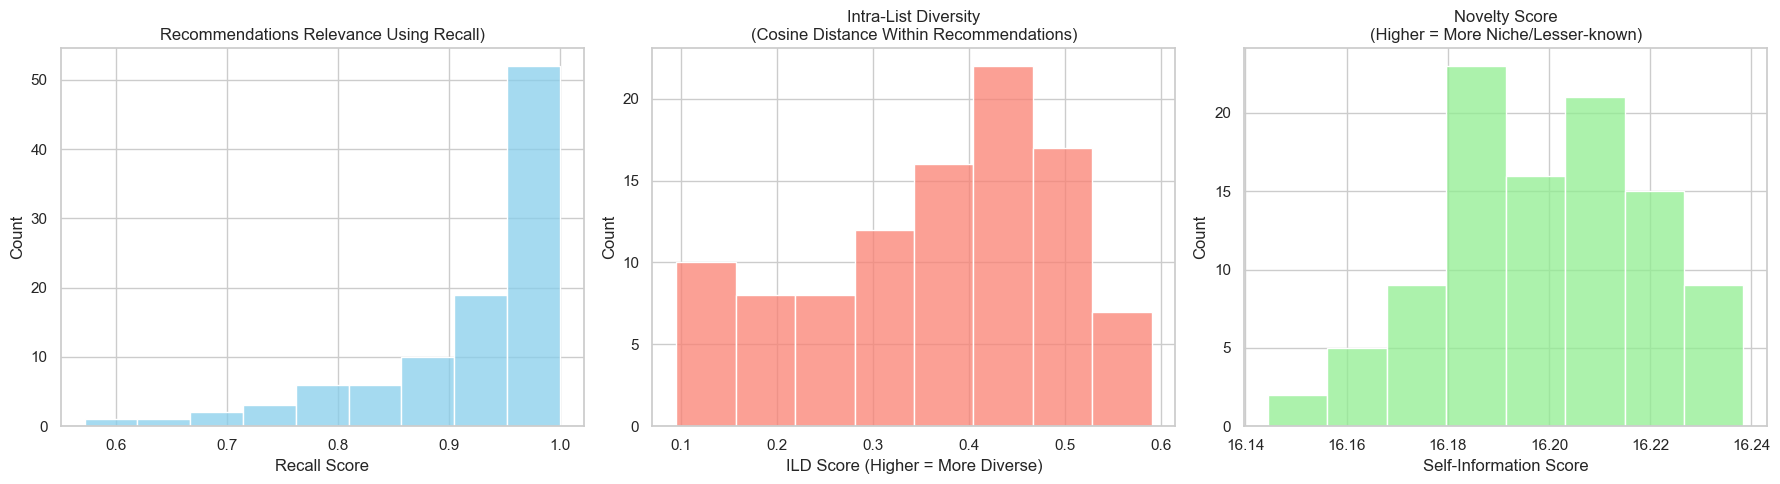

In [461]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recall
sns.histplot(df_metrics['Recall'], kde = False, ax=axes[0], color='skyblue')
axes[0].set_title('Recommendations Relevance Using Recall)')
axes[0].set_xlabel('Recall Score')
axes[0].set_ylabel('Count')

# Plot 2: Intra-List Diversity
sns.histplot(df_metrics['Intra-List Diversity'], kde = False, ax=axes[1], color='salmon')
axes[1].set_title('Intra-List Diversity\n(Cosine Distance Within Recommendations)')
axes[1].set_xlabel('ILD Score (Higher = More Diverse)')
axes[1].set_ylabel('Count')

# Plot 3: Novelty Distributions
sns.histplot(df_metrics['Novelty (Self-Info)'], kde = False, ax=axes[2], color='lightgreen')
axes[2].set_title('Novelty Score\n(Higher = More Niche/Lesser-known)')
axes[2].set_xlabel('Self-Information Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()